# ColourAnalyser
`capabilities/analysis/colour_analyser.py`

Computes a full HSV colour health profile from a plant image.  
**No model download. Pure OpenCV. < 10 ms per image.**

| Signal | What it means |
|--------|---------------|
| `green_ratio` | Fraction of healthy green pixels — high = healthy canopy |
| `yellow_ratio` | Fraction of yellowing pixels — elevated = chlorosis / N deficiency |
| `brown_ratio` | Fraction of brown/necrotic pixels — elevated = disease or drought |
| `health_index` | Composite score [0–1] — higher = healthier |
| `dominant_hue` | Most frequent hue value (0–179 OpenCV scale) |
| `saturation_mean` | Mean saturation — low = pale/etiolated, high = vibrant |
| `brightness_mean` | Mean brightness — low = dark or underexposed |

## Setup

In [2]:
import sys, os
sys.path.insert(0, os.path.abspath('../..'))

import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from capabilities.analysis.colour_analyser import ColourAnalyser
from sprout_detection.utils.image_gen import make_sprout_image, make_bare_soil_image

analyser = ColourAnalyser()
print('ColourAnalyser ready')

ColourAnalyser ready


## Generate test images

In [ ]:
import tempfile

tmp = tempfile.mkdtemp()
#healthy_path  = os.path.join(tmp, 'healthy.png')
healthy_path  = 'sprout.jpg'
stressed_path = os.path.join(tmp, 'stressed.png')
bare_path     = os.path.join(tmp, 'bare.png')

cv2.imwrite(healthy_path,  make_sprout_image(seed=1))

# Stressed image: shift the sprout hue toward yellow
img = make_sprout_image(seed=2)
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV).astype(np.float32)
hsv[:,:,0] = np.clip(hsv[:,:,0] - 15, 0, 179)   # shift green → yellow
hsv[:,:,1] = np.clip(hsv[:,:,1] * 0.7, 0, 255)   # desaturate
cv2.imwrite(stressed_path, cv2.cvtColor(hsv.astype(np.uint8), cv2.COLOR_HSV2BGR))

cv2.imwrite(bare_path, make_bare_soil_image(seed=3))

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, (path, title) in zip(axes, [(healthy_path, 'Healthy'), (stressed_path, 'Stressed'), (bare_path, 'Bare soil')]):
    img = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
    ax.imshow(img); ax.set_title(title, fontsize=12); ax.axis('off')
plt.suptitle('Test images', fontsize=13)
plt.tight_layout()
plt.show()

## Basic usage — analyse a single image

In [10]:
result = analyser.analyse('sprout.jpg')

print(f'Health index   : {result.health_index:.3f}')
print(f'Green ratio    : {result.green_ratio:.3f}')
print(f'Yellow ratio   : {result.yellow_ratio:.3f}')
print(f'Brown ratio    : {result.brown_ratio:.3f}')
print(f'Dominant hue   : {result.dominant_hue}  (0=red, 60=yellow, 120=green)')
print(f'Saturation mean: {result.saturation_mean:.1f}')
print(f'Brightness mean: {result.brightness_mean:.1f}')
print(f'Summary        : {result.summary}')
print(f'Inference time : {result.duration_ms:.1f} ms')

Health index   : 0.026
Green ratio    : 0.052
Yellow ratio   : 0.004
Brown ratio    : 0.639
Dominant hue   : 11  (0=red, 60=yellow, 120=green)
Saturation mean: 142.5
Brightness mean: 53.7
Summary        : Severely stressed — 5.2% green, 63.9% browning
Inference time : 7.5 ms


## Compare healthy vs stressed vs bare

In [ ]:
results = {
    'Healthy' : analyser.analyse(healthy_path),
    'Stressed': analyser.analyse(stressed_path),
    'Bare soil': analyser.analyse(bare_path),
}

metrics = ['health_index', 'green_ratio', 'yellow_ratio', 'brown_ratio']
labels  = list(results.keys())
colors  = ['#2ecc71', '#f39c12', '#95a5a6']

fig, axes = plt.subplots(1, len(metrics), figsize=(14, 4))
for ax, metric in zip(axes, metrics):
    vals = [getattr(r, metric) for r in results.values()]
    bars = ax.bar(labels, vals, color=colors, edgecolor='white', linewidth=0.8)
    ax.set_title(metric.replace('_', ' ').title(), fontsize=10)
    ax.set_ylim(0, 1.0)
    ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.02,
                f'{val:.2f}', ha='center', va='bottom', fontsize=9)
plt.suptitle('Colour Health Metrics — Three Plant States', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## All colour band ratios

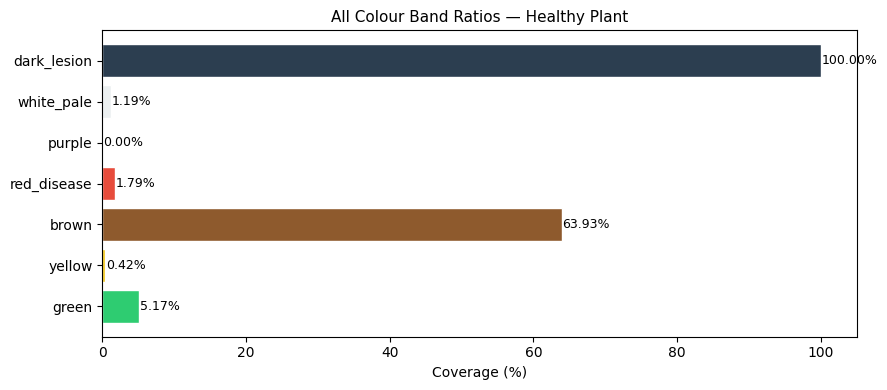

In [11]:
result = analyser.analyse(healthy_path)

bands = result.band_ratios
band_names = list(bands.keys())
band_vals  = [bands[k] * 100 for k in band_names]

fig, ax = plt.subplots(figsize=(9, 4))
bar_colors = ['#2ecc71','#f1c40f','#8e5a2d','#e74c3c','#9b59b6','#ecf0f1','#2c3e50']
bars = ax.barh(band_names, band_vals, color=bar_colors[:len(band_names)], edgecolor='white')
for bar, val in zip(bars, band_vals):
    ax.text(val + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}%', va='center', fontsize=9)
ax.set_xlabel('Coverage (%)')
ax.set_title('All Colour Band Ratios — Healthy Plant', fontsize=11)
plt.tight_layout()
plt.show()

## Hue histogram — what colours dominate?

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

hue_regions = [
    (0,  15,  '#e74c3c', 'Red'),
    (15, 35,  '#f39c12', 'Orange/Yellow'),
    (35, 85,  '#2ecc71', 'Green'),
    (85, 130, '#1abc9c', 'Cyan'),
    (130,179, '#3498db', 'Blue/Purple'),
]

for ax, (name, r) in zip(axes, results.items()):
    x = np.arange(180)
    y = np.array(r.histogram_h)
    ax.fill_between(x, y, alpha=0.4, color='gray')
    ax.plot(x, y, color='gray', linewidth=0.8)
    # Shade hue regions
    for h_lo, h_hi, col, _ in hue_regions:
        ax.axvspan(h_lo, h_hi, alpha=0.12, color=col)
    ax.axvline(r.dominant_hue, color='red', linewidth=1.5, linestyle='--', label=f'Dominant hue={r.dominant_hue}')
    ax.set_title(name, fontsize=10)
    ax.set_xlabel('Hue (0–179)')
    ax.legend(fontsize=8)

axes[0].set_ylabel('Normalised frequency')
patches = [mpatches.Patch(color=c, label=l, alpha=0.5) for _, _, c, l in hue_regions]
fig.legend(handles=patches, loc='upper right', fontsize=8, ncol=5)
plt.suptitle('Hue Histograms', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## `diff()` — track change between two time points

In [ ]:
r_before = results['Healthy']
r_after  = results['Stressed']

delta = analyser.diff(r_before, r_after)

print('Change from Healthy → Stressed:')
for field, change in delta.items():
    arrow = '▲' if change > 0 else ('▼' if change < 0 else '=')
    print(f'  {field:<20} {arrow}  {change:+.4f}')

## Using a segmentation mask (analyse only plant pixels)

In [13]:
from capabilities.segmentation.hsv_segmentor import HSVSegmentor

seg = HSVSegmentor()
seg_result = seg.segment(healthy_path, profile='green_plant')

# Analyse only the segmented plant region — excludes pot and background
result_masked = analyser.analyse(healthy_path, mask=seg_result.mask)
result_full   = analyser.analyse(healthy_path)

print('With mask (plant pixels only):')
print(f'  health_index : {result_masked.health_index:.3f}')
print(f'  green_ratio  : {result_masked.green_ratio:.3f}')
print()
print('Without mask (whole image):')
print(f'  health_index : {result_full.health_index:.3f}')
print(f'  green_ratio  : {result_full.green_ratio:.3f}')

With mask (plant pixels only):
  health_index : 0.931
  green_ratio  : 0.004

Without mask (whole image):
  health_index : 0.026
  green_ratio  : 0.052


## JSON serialisation

In [ ]:
import json
d = result.to_dict()
# Print selected fields (histogram is long)
summary_keys = ['health_index','green_ratio','yellow_ratio','brown_ratio',
                'dominant_hue','saturation_mean','brightness_mean','summary','duration_ms']
print(json.dumps({k: d[k] for k in summary_keys}, indent=2))